# Theory vs. experiment — the $\ell=1$ focusing scan (`7-27-26 / 29_n15`)

This notebook puts the **theoretical waterfalls** of
[`notebooks/OFVB_mask_amplitude_v5.ipynb`](notebooks/OFVB_mask_amplitude_v5.ipynb) directly next to
the **measured** $\ell=1$ focusing data, and starts plotting the measured beam against the
dimensionless axial coordinate $\tau$.

**Theory side** (dimensionless diffraction, reproduced from OFVB):
optimize the Bessel parameter $\beta$, build the three pupil masks **Optimal / PFBZ / FBZ**, and
propagate each to an intensity map $I(\tau,\rho)$. The design focus sits at
$\tau_f = 1/(2\pi n_0)$; the transverse coordinate is $x = a\,\rho$.

**Experiment side** (verbatim stitched pipeline from `waterfall_stitched_Full.ipynb`):
load the `7-27-26/29_n15/{FBZ,Optimal,PFBZ}` scans for $\ell=1$, track the centroid, take a
transverse slice per frame, and **stitch** the overlapping stage segments onto one global $z$ (mm)
axis. $\ell=1$ Optimal has the extra `60mm-85mm` segment, so it is the longest scan.

### The one modeling choice: how $z$ (mm) maps to $\tau$

The raw theory relation $z = k a^2\tau$ gives $z_f\!\approx\!88$ m for $n_0=15$ — the bench focuses
within centimetres because a **4f system + final lens** rescales the axial coordinate (see the
README). So we do **not** use $k a^2$. Instead we use a **focus-anchored linear map through the
origin**, which the README supports (frame `0000` is the SLM image plane, i.e. the mask plane
$\tau=0$):

$$\tau \;=\; \tau_f\,\frac{z}{z_{\mathrm{focus,exp}}},\qquad z=0\leftrightarrow\tau=0 .$$

Each condition's measured width-minimum is pinned to $\tau_f$. The scale is exposed as a tunable,
so a physically-calibrated value can replace the focus anchor later.

### Plan / sections

1. **Theory** — $\beta$-optimization, the three masks ($n_0=15$), propagation, and the three
   theoretical waterfalls drawn on a $\tau$ axis extended to cover the experimental range.
2. **Theory analysis** — transverse **RMS width (mm) vs $\tau$** from each theoretical map, and the
   theoretical focus.
3. **Experiment** — the stitched pipeline for $\ell=1$, all three conditions, width vs $z$ (RMS + LG).
4. **Bridge & compare** — map $z\to\tau$ and overlay measured width-vs-$\tau$ on the theory curves;
   side-by-side waterfalls on a shared $\tau$ axis.


## Shared configuration

$\ell$, the focusing parameter $n_0$, aperture radius $a$, wavelength, and the camera pixel pitch.
`N0 = 15` matches the `29_n15` mask; `PIXEL_PITCH_MM = 0.0048` is the camera pitch used throughout
the experimental notebooks. Note the theory and camera transverse scales differ by the (unknown) 4f
magnification, so the width comparison later is by *shape*, not absolute mm.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.special import jv
from scipy.optimize import minimize_scalar, curve_fit

plt.rcParams["figure.dpi"] = 130
np.set_printoptions(precision=6, suppress=True)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "focusing_images"
SCAN_ROOT = DATA_ROOT / "7-27-26" / "29_n15"
OUT_ROOT = REPO_ROOT / "outputs" / "theory_vs_experiment_l1"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# --- physical / dimensionless parameters ----------------------------------
L = 1                       # OAM charge for this comparison
N0 = 14                     # focusing parameter (matches OFVB_mask_amplitude_v5)
A = 29e-3 *1/4                   # aperture radius [m]
LAM = 633e-9                # wavelength [m]
K = 2 * np.pi / LAM         # optical wavenumber [1/m]

TAU_F = 1.0 / (2 * np.pi * N0)
Z_F = K * A**2 * TAU_F      # ideal focal distance -- NOT the bench distance

PIXEL_PITCH_MM = 0.0048     # camera pixel pitch [mm/px]

print(f"l           = {L}")
print(f"n0          = {N0}")
print(f"tau_f       = {TAU_F:.9f}")
print(f"z_f (ideal) = {Z_F:.3f} m   <- not physical here (4f + lens rescales z)")
print(f"pixel pitch = {PIXEL_PITCH_MM} mm/px")
assert SCAN_ROOT.is_dir(), f"missing {SCAN_ROOT}"

l           = 1
n0          = 14
tau_f       = 0.011368210
z_f (ideal) = 5.931 m   <- not physical here (4f + lens rescales z)
pixel pitch = 0.0048 mm/px


# 1 · Theory

## 1.1 Optimize $\beta$ (reproduced from OFVB)

Same optimization as OFVB: maximise the larger focusing eigenvalue $\lambda_+(\beta)$ over the
Bessel scale $\beta$, using $\tau_f$ for $n_0=15$.

In [2]:
rho_beta = np.linspace(0.0, 1.0, 40001)


def I0_of_beta(beta):
    J = jv(L, beta * rho_beta)
    return np.trapz(rho_beta * J**2, rho_beta) / (2 * np.pi)


def R_of_beta(beta):
    J = jv(L, beta * rho_beta)
    phase = np.exp(1j * rho_beta**2 / TAU_F)
    return np.trapz(rho_beta * J**2 * phase, rho_beta) / (2 * np.pi)


def lambda_plus(beta):
    return (I0_of_beta(beta) + np.abs(R_of_beta(beta))) / (2 * TAU_F**2)


opt = minimize_scalar(lambda b: -lambda_plus(b), bounds=(1e-4, 20.0),
                      method="bounded", options={"xatol": 1e-6})
beta_opt = float(opt.x)
print(f"beta_opt   = {beta_opt:.9f}")
print(f"lambda_opt = {lambda_plus(beta_opt):.9f}")

beta_opt   = 2.391468288
lambda_opt = 83.926160274


/tmp/ipykernel_51070/999029743.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(rho_beta * J**2, rho_beta) / (2 * np.pi)
/tmp/ipykernel_51070/999029743.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(rho_beta * J**2 * phase, rho_beta) / (2 * np.pi)


## 1.2 Build the three masks (reproduced from OFVB)

Optimal, PFBZ, FBZ pupil fields, each $L^2$-normalised with $2\pi\int_0^1\rho|\psi|^2\,d\rho=1$.

In [3]:
Nrho_in = 4000
rho_in = np.linspace(0.0, 1.0, Nrho_in)

J_beta = jv(L, beta_opt * rho_in)
I0_beta = np.trapz(rho_in * J_beta**2, rho_in) / (2 * np.pi)
R_beta = np.trapz(rho_in * J_beta**2 * np.exp(1j * rho_in**2 / TAU_F), rho_in) / (2 * np.pi)

theta = 0.5 * np.angle(R_beta)
phase_arg = rho_in**2 / (2 * TAU_F) - theta


def normalize_pupil(psi_raw, rho):
    norm = np.sqrt(2 * np.pi * np.trapz(rho * np.abs(psi_raw)**2, rho))
    return psi_raw / norm


# Optimal
psi_opt = normalize_pupil(J_beta * np.cos(phase_arg), rho_in)
# PFBZ (binary +/-1 amplitude)
psi_pfbz = normalize_pupil((2 * np.sqrt(np.pi)) * np.where(J_beta * np.cos(phase_arg) >= 0, 1.0, -1.0), rho_in)
# FBZ (Bessel amplitude, binary sign of cos)
psi_fbz = normalize_pupil((J_beta / np.sqrt(I0_beta)) * np.where(np.cos(phase_arg) >= 0, 1.0, -1.0), rho_in)

rho_star = beta_opt * TAU_F
r_star = A * rho_star
print(f"theta    = {theta:.6f} rad")
print(f"rho_star = {rho_star:.6f}   ->  ring radius r_star = {1e3 * r_star:.4f} mm")

MASKS = {"Optimal": psi_opt, "PFBZ": psi_pfbz, "FBZ": psi_fbz}

theta    = -0.820723 rad
rho_star = 0.027187   ->  ring radius r_star = 0.1971 mm


/tmp/ipykernel_51070/2323507320.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I0_beta = np.trapz(rho_in * J_beta**2, rho_in) / (2 * np.pi)
/tmp/ipykernel_51070/2323507320.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  R_beta = np.trapz(rho_in * J_beta**2 * np.exp(1j * rho_in**2 / TAU_F), rho_in) / (2 * np.pi)
/tmp/ipykernel_51070/2323507320.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(2 * np.pi * np.trapz(rho * np.abs(psi_raw)**2, rho))


## 1.3 Propagate each mask to $I(\tau,\rho)$

Verbatim Fresnel propagator from OFVB. The $\tau$ grid is extended to `TAU_MAX = TAU_MAX_FACTOR *
tau_f` so it spans the whole experimental scan once mapped (the experiment reaches a few $\tau_f$).
`Nrho_out` is raised to resolve the small focal ring.

In [4]:
TAU_MAX_FACTOR = 2.0                 # cover the experimental range in units of tau_f
NTAU = 320
NRHO_OUT = 700

TAU_MAX = TAU_MAX_FACTOR * TAU_F
taus = np.concatenate(([0.0], np.linspace(TAU_F / 250, TAU_MAX, NTAU - 1)))
rho_out = np.linspace(0.0, 1.0, NRHO_OUT)


def propagate_mask(psi_radial, rho_in, rho_out, taus, l):
    """Return I(tau, rho), globally peak-normalised (verbatim from OFVB)."""
    intensity = np.zeros((len(taus), len(rho_out)), dtype=float)
    intensity[0, :] = np.abs(np.interp(rho_out, rho_in, psi_radial))**2

    rho_prime = rho_in[None, :]
    psi_row = psi_radial[None, :]
    rho_col = rho_out[:, None]
    for j, tau in enumerate(taus[1:], start=1):
        phase_in = np.exp(1j * rho_prime**2 / (2 * tau))
        bessel = jv(l, rho_col * rho_prime / tau)
        integrand = rho_prime * phase_in * bessel * psi_row
        radial_int = np.trapz(integrand, rho_in, axis=1)
        amp = ((-1j)**l) / (1j * tau) * np.exp(1j * rho_out**2 / (2 * tau)) * radial_int
        intensity[j, :] = np.abs(amp)**2
    intensity /= intensity.max()
    return intensity


THEORY = {}
for name, psi in MASKS.items():
    THEORY[name] = propagate_mask(psi, rho_in, rho_out, taus, L)
    print(f"{name:>8}: I(tau,rho) {THEORY[name].shape}  peak-normalised")

/tmp/ipykernel_51070/2365531469.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  radial_int = np.trapz(integrand, rho_in, axis=1)


 Optimal: I(tau,rho) (320, 700)  peak-normalised


    PFBZ: I(tau,rho) (320, 700)  peak-normalised


     FBZ: I(tau,rho) (320, 700)  peak-normalised


## 1.4 Theoretical waterfalls on the $\tau$ axis

Transverse cross-section $I(\tau, x)$ along $y=0$ for each mask, with $x = a\rho$ (mm). The design
focus $\tau_f$ is dashed. This is the OFVB waterfall, transposed so $\tau$ is horizontal to match the
experiment's later orientation.

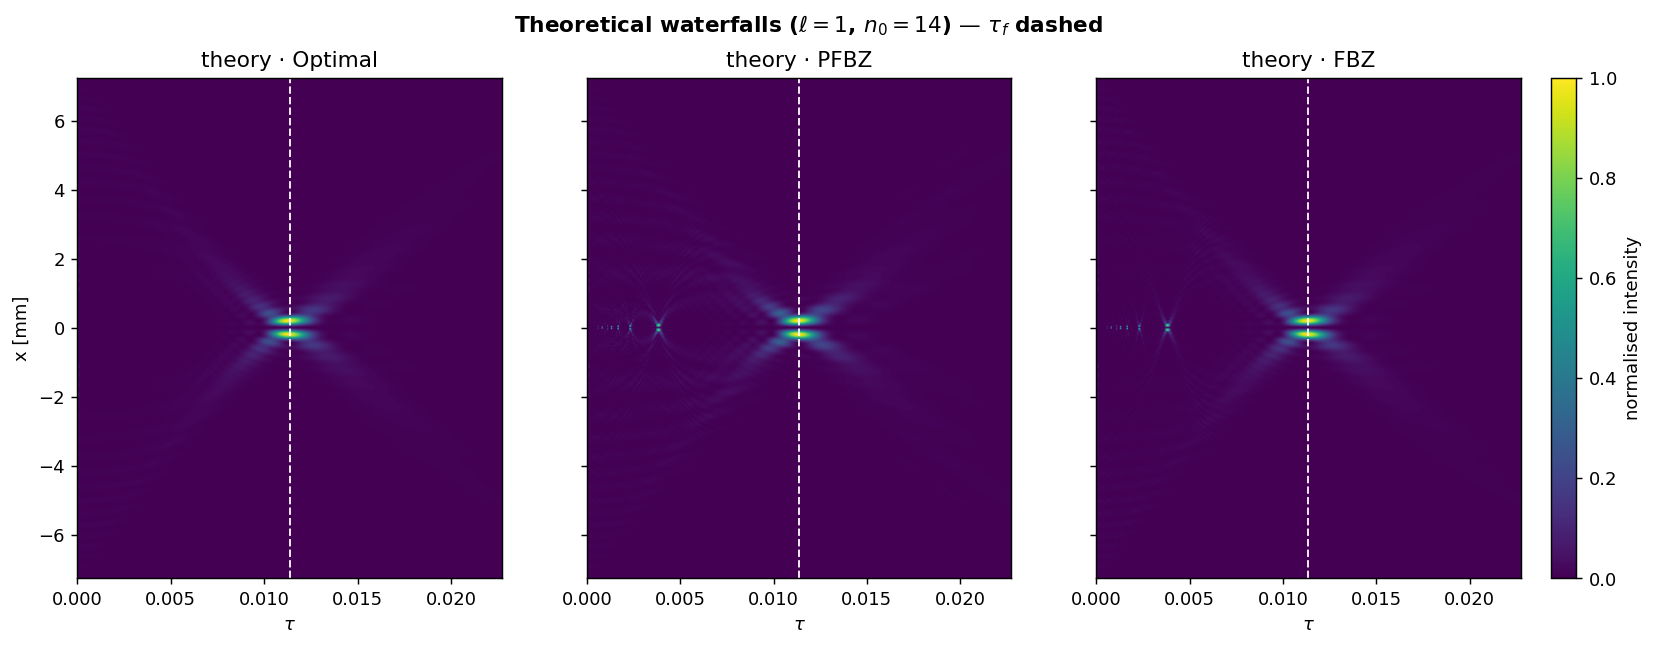

In [5]:
def theory_x_map(intensity_tau_rho, rho_out, n_x=901):
    """Mirror the radial map to a symmetric transverse profile I(tau, x), x in mm."""
    x_unit = np.linspace(-1.0, 1.0, n_x)
    x_mm = 1e3 * A * x_unit
    img = np.zeros((len(taus), n_x))
    for j in range(len(taus)):
        img[j] = np.interp(np.abs(x_unit), rho_out, intensity_tau_rho[j])
    return x_mm, img


fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), sharey=True)
for ax, (name, I) in zip(axes, THEORY.items()):
    x_mm, img = theory_x_map(I, rho_out)
    im = ax.imshow(img.T, origin="lower", aspect="auto",
                   extent=[taus[0], taus[-1], x_mm[0], x_mm[-1]], cmap="viridis", vmin=0, vmax=1)
    ax.axvline(TAU_F, color="w", ls="--", lw=1.1, alpha=0.9)
    ax.set_xlabel(r"$\tau$")
    ax.set_title(f"theory · {name}")
    ax.set_ylim(-1e3 * A, 1e3 * A)           # full aperture scale (matches v5)
axes[0].set_ylabel("x [mm]")
fig.colorbar(im, ax=axes, label="normalised intensity", fraction=0.025, pad=0.02)
fig.suptitle(f"Theoretical waterfalls ($\\ell={L}$, $n_0={N0}$) — $\\tau_f$ dashed", fontweight="bold")
fig.savefig(OUT_ROOT / "theory_waterfalls.png", dpi=150, bbox_inches="tight")
plt.show()

## 1.5 Theory beam-width vs $\tau$

The theory analogue of the measured focus curve. Two width measures per mask, computed over the
**full aperture** (no experimental crop — the theory field is not lens-demagnified, so its focal
ring is $\sim$`r_star` mm inside a $\pm a$ = $\pm29$ mm envelope):

* **radial RMS radius** — area-weighted ($\rho\,d\rho$) RMS of $I(\tau,\rho)$; its minimum is the
  theoretical focus and lands at $\approx\tau_f$ by construction.
* **ring radius** — radius of peak intensity, searched only in the focal band $\tau>0.3\,\tau_f$ to
  avoid the on-axis artefact as $\tau\to0$; equals `r_star` at $\tau_f$.

Absolute mm here are **theory-plane** mm, a factor of the (unknown) 4f magnification away from the
camera mm — so it is the *shape* of these curves, not their absolute scale, that is compared with
experiment later.

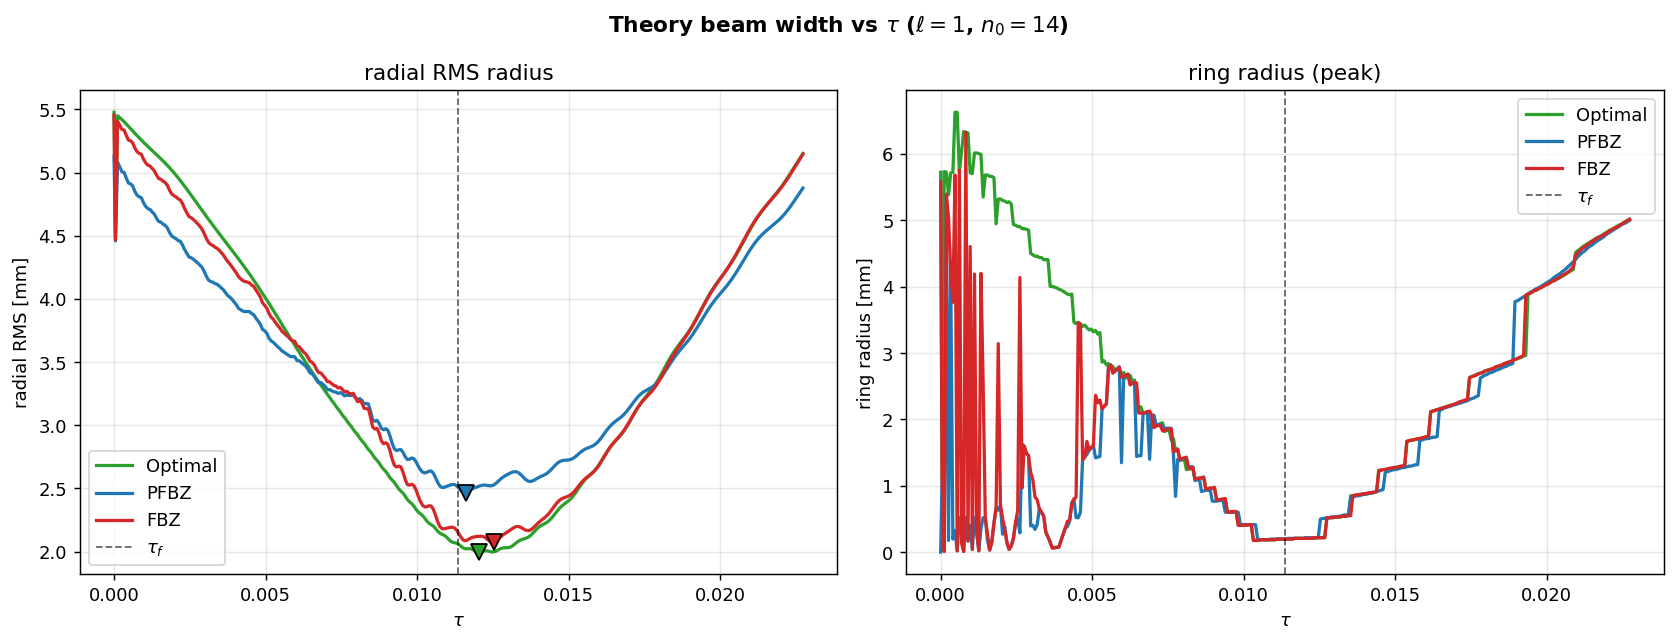

theoretical focus (min radial RMS, in the focal band):
   Optimal: tau_focus = 0.012033  (1.058 tau_f)
      PFBZ: tau_focus = 0.011605  (1.021 tau_f)
       FBZ: tau_focus = 0.012533  (1.102 tau_f)


In [6]:
def theory_radial_rms_mm(intensity_row):
    x_mm = 1e3 * A * rho_out
    w = np.clip(intensity_row, 0, None) * rho_out      # area weight rho drho
    tot = w.sum()
    return float(np.sqrt((w * x_mm**2).sum() / tot)) if tot > 0 else np.nan


def theory_ring_mm(intensity_row):
    return float(1e3 * A * rho_out[int(np.argmax(intensity_row))])


THEORY_WIDTH = {name: np.array([theory_radial_rms_mm(I[j]) for j in range(len(taus))])
                for name, I in THEORY.items()}
THEORY_RING = {name: np.array([theory_ring_mm(I[j]) for j in range(len(taus))])
               for name, I in THEORY.items()}
THEORY_FOCUS = {}

focus_band = taus > 0.3 * TAU_F                        # ignore the tau->0 on-axis artefact
tcol = {"Optimal": "C2", "PFBZ": "C0", "FBZ": "C3"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
for name in THEORY:
    w, ring = THEORY_WIDTH[name], THEORY_RING[name]
    j = int(np.nanargmin(np.where(focus_band, w, np.inf)))
    THEORY_FOCUS[name] = float(taus[j])
    axes[0].plot(taus, w, "-", lw=1.8, color=tcol[name], label=name)
    axes[0].plot(taus[j], w[j], "v", color=tcol[name], ms=9, markeredgecolor="k", zorder=5)
    axes[1].plot(taus, ring, "-", lw=1.8, color=tcol[name], label=name)
for ax, ttl, yl in zip(axes, ["radial RMS radius", "ring radius (peak)"],
                       ["radial RMS [mm]", "ring radius [mm]"]):
    ax.axvline(TAU_F, color="k", ls="--", lw=1.0, alpha=0.6, label=r"$\tau_f$")
    ax.set_xlabel(r"$\tau$"); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle(f"Theory beam width vs $\\tau$ ($\\ell={L}$, $n_0={N0}$)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "theory_width_vs_tau.png", dpi=150, bbox_inches="tight")
plt.show()

print("theoretical focus (min radial RMS, in the focal band):")
for name, t in THEORY_FOCUS.items():
    print(f"  {name:>8}: tau_focus = {t:.6f}  ({t / TAU_F:.3f} tau_f)")

# 2 · Experiment — the stitched $\ell=1$ scan

Everything below is the **verbatim** pipeline of `waterfall_stitched_Full.ipynb`, configured for
$\ell=1$ only and all three conditions. Optimal includes its extra `60mm-85mm` segment.

## 2.1 Acquisition / pipeline constants (verbatim)

In [7]:
RUN = "29_n15_7-27-26"

def nominal_start(folder_name: str) -> float:
    m = re.match(r"(\d+)mm-(\d+)mm", folder_name)
    if not m:
        raise ValueError(f"cannot parse a nominal start from folder {folder_name!r}")
    return float(m.group(1))

# l=1 Optimal has the extra 60mm-85mm segment; FBZ / PFBZ do not (auto-skipped if missing).
CONDITION_SEGMENTS = {
    "FBZ":     ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
    "Optimal": ["0mm-25mm", "20mm-45mm", "40mm-65mm", "60mm-85mm"],
    "PFBZ":    ["0mm-25mm", "20mm-45mm", "40mm-65mm"],
}
ELLS = [1]                           # this comparison is l=1 only

STEP_MM = 0.5

# --- slicing (verbatim) ---------------------------------------------------
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200

# --- centroid finding (verbatim) ------------------------------------------
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200

assert SLICE_AXIS in ("x", "y")

## 2.2 Frame loading, background, centroid — verbatim

In [8]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


@dataclass(frozen=True)
class Segment:
    cond: str
    seg: str
    ell: int
    directory: Path
    nominal_start_mm: float


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    tifs = [p for p in directory.glob("*.tif") if not p.name.startswith(".")]
    return sorted(tifs, key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    csv = directory / "positions.csv"
    if csv.is_file():
        table = pd.read_csv(csv)
        by_name = dict(zip(table["image"], table["position_mm"]))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
        print(f"  ! {directory.parent.name}/{directory.name}: positions.csv incomplete -- using index*{STEP_MM}")
    else:
        print(f"  ! {directory.parent.name}/{directory.name}: no positions.csv -- using index*{STEP_MM}")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    return cy, cx

## 2.3 Process one segment into a waterfall + width trace — verbatim

In [9]:
@dataclass
class SegWaterfall:
    cond: str
    seg: str
    ell: int
    nominal_start_mm: float
    waterfall: np.ndarray
    s_px: np.ndarray
    z_local: np.ndarray
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    width_px: np.ndarray
    onaxis: np.ndarray


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def process_segment(segment: Segment) -> SegWaterfall:
    paths = frame_paths(segment.directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {segment.directory}")
    z_local = load_local_positions(segment.directory, paths)
    frames = load_frames(paths)

    centroids = np.array([find_centroid(f) for f in frames])
    centroid_y, centroid_x = centroids[:, 0], centroids[:, 1]

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    centre_idx = int(np.argmin(np.abs(s_px)))
    onaxis = waterfall[:, centre_idx].astype(float)

    return SegWaterfall(
        cond=segment.cond, seg=segment.seg, ell=segment.ell,
        nominal_start_mm=segment.nominal_start_mm,
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x, width_px=width_px, onaxis=onaxis,
    )

## 2.4 Process every segment (the slow cell — a couple of minutes)

In [10]:
data: dict[str, dict[int, dict[str, SegWaterfall]]] = {}

for cond, seg_labels in CONDITION_SEGMENTS.items():
    cdir = SCAN_ROOT / cond
    data[cond] = {ell: {} for ell in ELLS}
    for ell in ELLS:
        for seg in seg_labels:
            directory = cdir / seg / f"l={ell}"
            if not directory.is_dir():
                continue
            data[cond][ell][seg] = process_segment(Segment(cond, seg, ell, directory, nominal_start(seg)))
        if data[cond][ell]:
            print(f"{cond:>8}  l={ell}  segs={list(data[cond][ell])}")
    data[cond] = {ell: segs for ell, segs in data[cond].items() if segs}

     FBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']


 Optimal  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm', '60mm-85mm']


    PFBZ  l=1  segs=['0mm-25mm', '20mm-45mm', '40mm-65mm']


## 2.5 Segment offsets from `waterfall_offsets.csv`

Absolute global starts per `(condition, ell, segment)`. The extended `60mm-85mm` Optimal segment is
not in the file, so it falls back to the 3-seg notebook's default (64.5 mm); edit the file and re-run
if it needs nudging.

In [11]:
OFFSETS_FILE = REPO_ROOT / "waterfall_offsets.csv"
DEFAULT_START = {"0mm-25mm": 0.0, "20mm-45mm": 24.0, "40mm-65mm": 44.5, "60mm-85mm": 64.5}


def default_for(seg: str) -> float:
    return DEFAULT_START.get(seg, nominal_start(seg))


existing: dict[tuple[str, int, str], float] = {}
if OFFSETS_FILE.is_file():
    prev = pd.read_csv(OFFSETS_FILE)
    for _, r in prev.iterrows():
        existing[(str(r["condition"]), int(r["ell"]), str(r["segment"]))] = float(r["start_mm"])

STARTS_MM: dict[str, dict[int, dict[str, float]]] = {}
for cond in data:
    STARTS_MM[cond] = {}
    for ell in data[cond]:
        STARTS_MM[cond][ell] = {}
        for seg in data[cond][ell]:
            STARTS_MM[cond][ell][seg] = existing.get((cond, ell, seg), default_for(seg))

for cond in STARTS_MM:
    for ell in STARTS_MM[cond]:
        print(f"{cond:>8} l={ell}: " + ", ".join(f"{s}@{v:.1f}" for s, v in STARTS_MM[cond][ell].items()))

     FBZ l=1: 0mm-25mm@0.0, 20mm-45mm@22.5, 40mm-65mm@45.5
 Optimal l=1: 0mm-25mm@0.0, 20mm-45mm@24.5, 40mm-65mm@45.0, 60mm-85mm@64.5
    PFBZ l=1: 0mm-25mm@0.0, 20mm-45mm@21.0, 40mm-65mm@43.5


## 2.6 Stitch helpers — verbatim

In [12]:
def seg_order(cond: str, ell: int) -> list[str]:
    return [s for s in CONDITION_SEGMENTS[cond] if s in data[cond][ell]]


def global_z(sw: SegWaterfall, ell: int) -> np.ndarray:
    return sw.z_local + STARTS_MM[sw.cond][ell][sw.seg]


BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    cond: str
    ell: int
    mode: str
    waterfall: np.ndarray
    s_px: np.ndarray
    z_mm: np.ndarray
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    coverage: np.ndarray

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src, water_src, z_grid):
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1)
    return out, covered


def _blend_weights(mode, order, z_grid, covers):
    order = [lbl for lbl in order if lbl in covers]
    w = {lbl: covers[lbl].astype(float) for lbl in order}
    if mode == "average":
        pass
    elif mode == "hardcut":
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            mid = 0.5 * (z_ov.min() + z_ov.max())
            w[left][both] = np.where(z_ov <= mid, 1.0, 0.0)
            w[right][both] = np.where(z_ov <= mid, 0.0, 1.0)
    else:  # crossfade
        for left, right in zip(order[:-1], order[1:]):
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp
    stack = np.stack([w[lbl] for lbl in order])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return {lbl: stack[i] for i, lbl in enumerate(order)}


def stitch(cond, ell, mode, z_grid):
    order = seg_order(cond, ell)
    sws = {lbl: data[cond][ell][lbl] for lbl in order}
    s_px = sws[order[0]].s_px
    for lbl, sw in sws.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped differently"
    maps, covers, zs = {}, {}, {}
    for lbl, sw in sws.items():
        z = global_z(sw, ell)
        m, cov = _resample_map(z, sw.waterfall, z_grid)
        maps[lbl], covers[lbl], zs[lbl] = m, cov, z
    weights = _blend_weights(mode, order, z_grid, covers)
    water = np.zeros_like(maps[order[0]])
    for lbl in order:
        water += weights[lbl][:, None] * maps[lbl]
    covered_any = np.any([covers[lbl] for lbl in order], axis=0)
    water[~covered_any] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak
    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in order:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], sws[lbl].centroid_x)
    coverage = np.sum([covers[lbl] for lbl in order], axis=0)
    return Stitched(cond, ell, mode, water, s_px, z_grid, cy, cx, coverage)

## 2.7 Build the stitched $\ell=1$ waterfalls

One global grid per condition; `CHOSEN_BLEND = "hardcut"` as in the source notebook.

In [13]:
CHOSEN_BLEND = "hardcut"

stitched: dict[str, Stitched] = {}
for cond in CONDITION_SEGMENTS:
    ell = ELLS[0]
    order = seg_order(cond, ell)
    z_hi = max(global_z(data[cond][ell][s], ell)[-1] for s in order)
    z_lo = min(global_z(data[cond][ell][s], ell)[0] for s in order)
    grid = np.arange(z_lo, z_hi + 0.5 * STEP_MM, STEP_MM)
    st = stitch(cond, ell, CHOSEN_BLEND, grid)
    stitched[cond] = st
    print(f"{cond:>8}: {st.waterfall.shape}  z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm  "
          f"brightest {st.brightest_z:.1f} mm")

     FBZ: (142, 401)  z 0.0..70.5 mm  brightest 46.0 mm
 Optimal: (180, 401)  z 0.0..89.5 mm  brightest 47.5 mm
    PFBZ: (138, 401)  z 0.0..68.5 mm  brightest 42.5 mm


## 2.8 Measured beam width vs $z$ (RMS + LG-$\ell$ fit)

RMS radius per stitched frame, plus the per-frame LG($\ell=1$) waist fit (verbatim from the source
notebook) whose RMS model is the physically correct width for a doughnut. We keep both curves in
pixels here; the mm conversion and $\tau$ mapping happen in section 3.

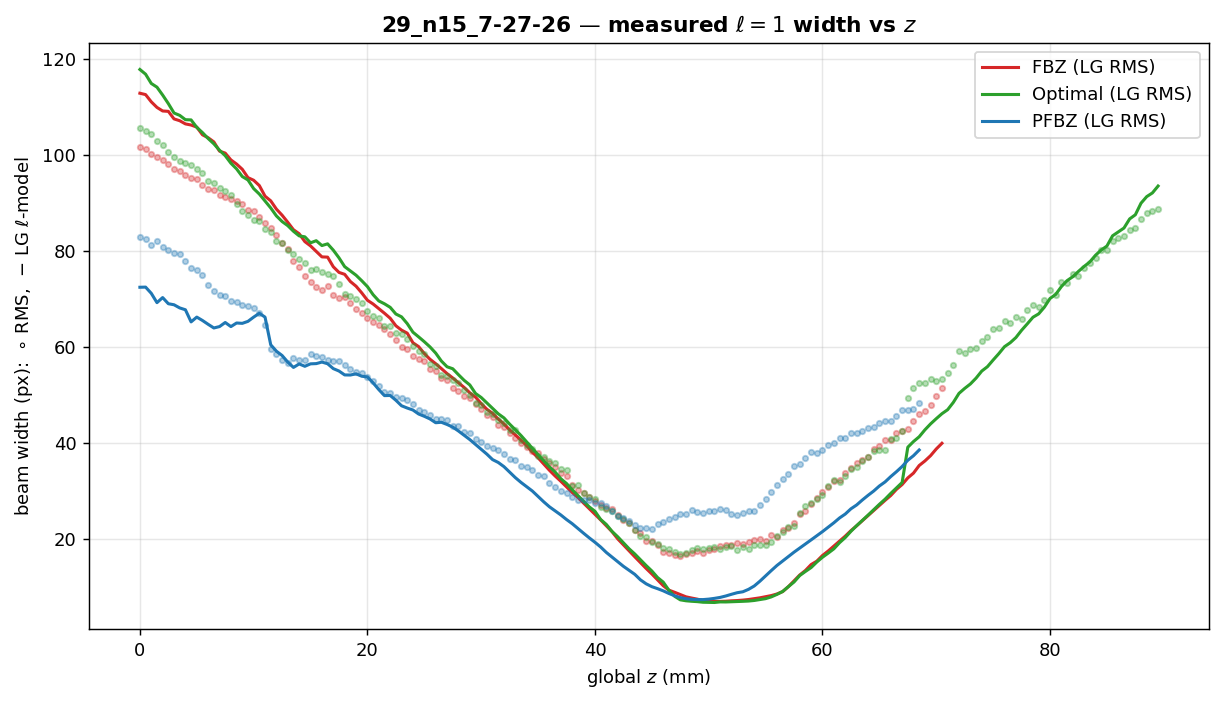

In [14]:
def lg_line_profile(s, amp, w, ell):
    x = 2.0 * (np.asarray(s, float) ** 2) / (w * w)
    return amp * x ** abs(ell) * np.exp(-x)


def lg_rms_from_w(w, ell):
    return 0.5 * np.asarray(w, float) * np.sqrt(2 * abs(ell) + 1)


def fit_lg_frame(profile, s_px, ell):
    y = np.clip(np.asarray(profile, float), 0, None)
    if not np.isfinite(y).any() or y.max() <= 0:
        return np.nan
    rms = _rms_width(y, s_px)
    if not np.isfinite(rms) or rms <= 0:
        return np.nan
    w0 = 2.0 * rms / np.sqrt(2 * abs(ell) + 1)
    amp0 = y.max() / max((abs(ell) ** abs(ell)) * np.exp(-abs(ell)), 1e-9)
    try:
        popt, _ = curve_fit(partial(lg_line_profile, ell=ell), s_px, y,
                            p0=(amp0, max(w0, 1.0)),
                            bounds=([0.0, 1e-3], [np.inf, np.inf]), maxfev=10000)
    except (RuntimeError, ValueError):
        return np.nan
    return float(popt[1])


def stitched_width(st):
    return np.array([_rms_width(row, st.s_px) for row in st.waterfall])


def lg_fit_stitched(st):
    w_fit = np.array([
        fit_lg_frame(row, st.s_px, st.ell) if cov > 0 else np.nan
        for row, cov in zip(st.waterfall, st.coverage)])
    return w_fit, lg_rms_from_w(w_fit, st.ell)


EXP_WIDTH = {}   # cond -> dict(z_mm, rms_px, lg_rms_px)
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ecol = {"Optimal": "C2", "PFBZ": "C0", "FBZ": "C3"}
for cond, st in stitched.items():
    rms = stitched_width(st)
    _, lg_rms = lg_fit_stitched(st)
    EXP_WIDTH[cond] = {"z_mm": st.z_mm, "rms_px": rms, "lg_rms_px": lg_rms, "coverage": st.coverage}
    ax.plot(st.z_mm, rms, "o", ms=3, color=ecol[cond], alpha=0.35)
    ax.plot(st.z_mm, lg_rms, "-", lw=1.7, color=ecol[cond], label=f"{cond} (LG RMS)")
ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel(r"beam width (px):  $\circ$ RMS,  $-$ LG $\ell$-model")
ax.set_title(f"{RUN} — measured $\\ell={ELLS[0]}$ width vs $z$", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "exp_width_vs_z.png", dpi=150, bbox_inches="tight")
plt.show()

# 3 · Bridge: map $z \to \tau$ and compare

## 3.1 The $z\to\tau$ map

Focus-anchored (default): each condition's measured LG focus $z_{\mathrm{focus}}$ is pinned to
$\tau_f$, with $z=0\to\tau=0$, so $\tau = \tau_f\,z/z_{\mathrm{focus}}$. Set `MANUAL_SCALE_MM` to a
number to instead use a single fixed $\tau = z/\text{scale}$ for **all** conditions (e.g. a
physically calibrated effective $k a^2$ in mm), which keeps the conditions' focus offsets visible
relative to theory.

In [15]:
MANUAL_SCALE_MM = None   # set to a float (mm per unit tau) to override the per-condition focus anchor


def exp_focus_z(cond):
    """Measured LG focus (z of minimum LG-RMS width) for a condition."""
    d = EXP_WIDTH[cond]
    w = d["lg_rms_px"].copy()
    w[d["coverage"] <= 0] = np.nan
    return float(d["z_mm"][np.nanargmin(w)])


EXP_TAU_SCALE = {}   # cond -> mm-per-tau
for cond in EXP_WIDTH:
    if MANUAL_SCALE_MM is not None:
        EXP_TAU_SCALE[cond] = MANUAL_SCALE_MM
    else:
        EXP_TAU_SCALE[cond] = exp_focus_z(cond) / TAU_F
    zf = exp_focus_z(cond)
    print(f"{cond:>8}: z_focus = {zf:5.1f} mm  ->  scale = {EXP_TAU_SCALE[cond]:.1f} mm/tau  "
          f"(tau at z_max = {EXP_WIDTH[cond]['z_mm'].max() / EXP_TAU_SCALE[cond] / TAU_F:.2f} tau_f)")


def z_to_tau(cond, z_mm):
    return np.asarray(z_mm) / EXP_TAU_SCALE[cond]

     FBZ: z_focus =  50.5 mm  ->  scale = 4442.2 mm/tau  (tau at z_max = 1.40 tau_f)
 Optimal: z_focus =  50.5 mm  ->  scale = 4442.2 mm/tau  (tau at z_max = 1.77 tau_f)
    PFBZ: z_focus =  49.5 mm  ->  scale = 4354.2 mm/tau  (tau at z_max = 1.38 tau_f)


## 3.2 Measured width-vs-$\tau$ overlaid on theory

The headline comparison. Because the theory-plane and camera transverse scales differ by the unknown
4f magnification, each curve is **normalised to its own focal minimum** — so all sit at 1.0 at focus
and the plot compares the *shape* of focusing (depth of focus, how fast the beam diverges either
side), which is scale-free. Dashed = theory mask (radial RMS); solid = measured condition (LG RMS).
$\tau_f$ is marked; both theory and the focus-anchored experiment minimise there by construction, so
what to read is the **width of the dip and the divergence rate**.

The companion panel keeps the measured curves in absolute **camera mm** vs $\tau$ (no theory), which
is the raw "experimental values against $\tau$".

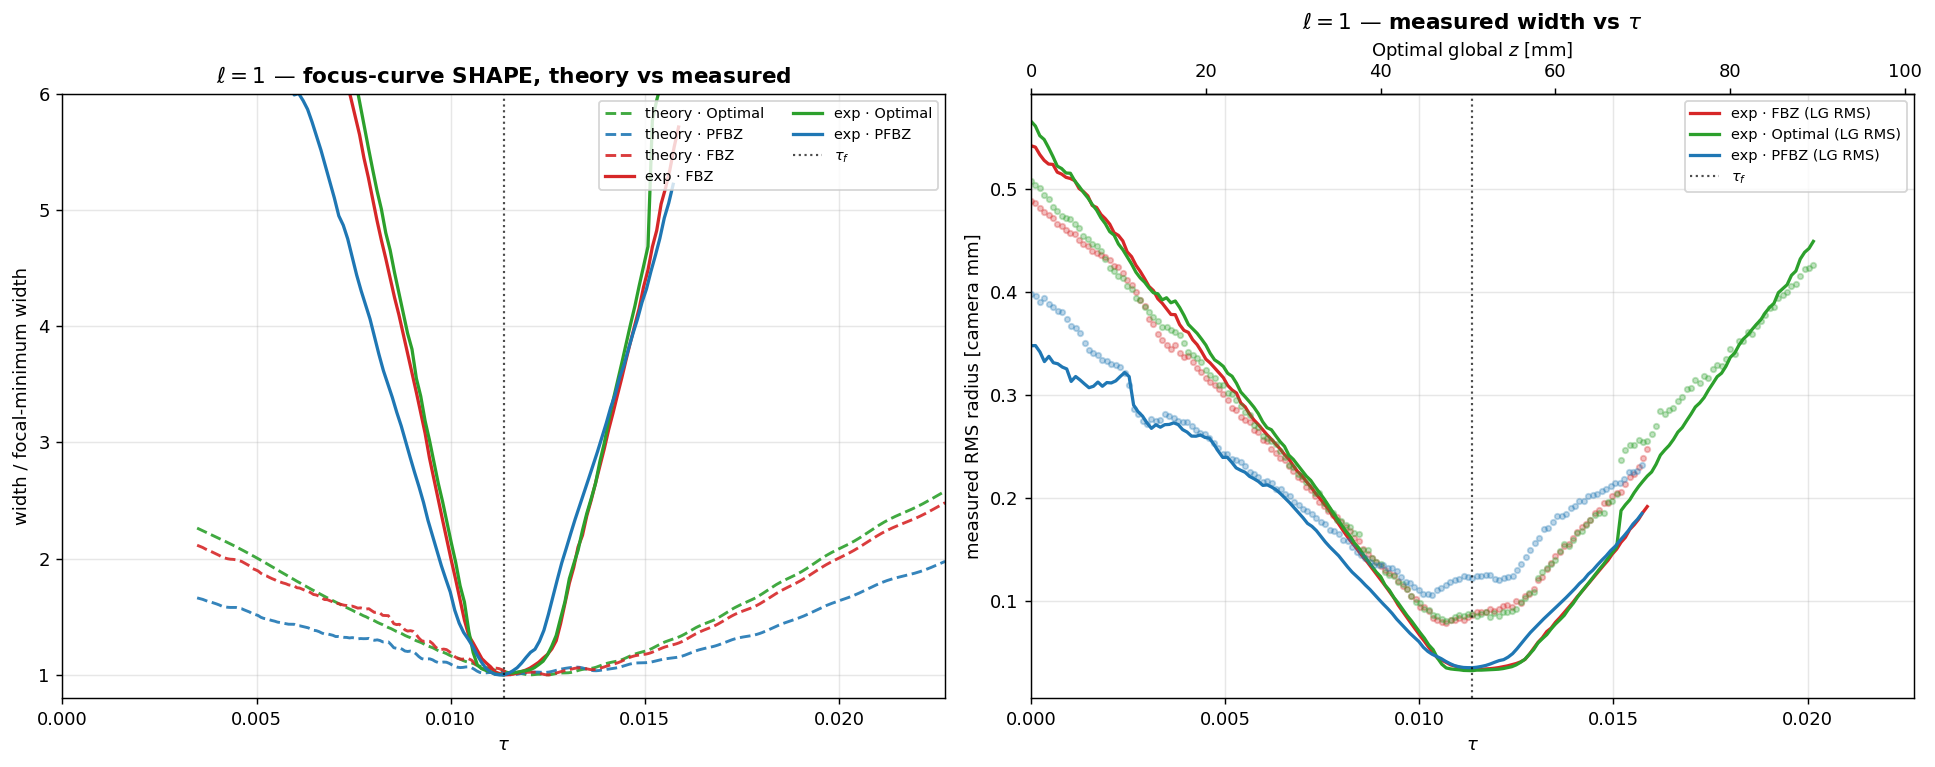

In [16]:
def norm_to_min(y):
    y = np.asarray(y, float)
    m = np.nanmin(y)
    return y / m if m and np.isfinite(m) else y


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left: shape comparison (normalised to focal minimum) ------------------
ax = axes[0]
for name, w in THEORY_WIDTH.items():
    ax.plot(taus, norm_to_min(np.where(taus > 0.3 * TAU_F, w, np.nan)), "--", lw=1.6,
            color=tcol[name], alpha=0.9, label=f"theory · {name}")
for cond, d in EXP_WIDTH.items():
    tau = z_to_tau(cond, d["z_mm"])
    ax.plot(tau, norm_to_min(d["lg_rms_px"]), "-", lw=1.8, color=ecol[cond],
            label=f"exp · {cond}")
ax.axvline(TAU_F, color="k", ls=":", lw=1.2, alpha=0.7, label=r"$\tau_f$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("width / focal-minimum width")
ax.set_xlim(0, TAU_MAX); ax.set_ylim(0.8, 6)
ax.set_title(f"$\\ell={L}$ — focus-curve SHAPE, theory vs measured", fontweight="bold")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)

# --- right: raw measured values in camera mm vs tau ------------------------
ax = axes[1]
for cond, d in EXP_WIDTH.items():
    tau = z_to_tau(cond, d["z_mm"])
    ax.plot(tau, d["rms_px"] * PIXEL_PITCH_MM, "o", ms=3, color=ecol[cond], alpha=0.30)
    ax.plot(tau, d["lg_rms_px"] * PIXEL_PITCH_MM, "-", lw=1.8, color=ecol[cond],
            label=f"exp · {cond} (LG RMS)")
ax.axvline(TAU_F, color="k", ls=":", lw=1.2, alpha=0.7, label=r"$\tau_f$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("measured RMS radius [camera mm]")
ax.set_xlim(0, TAU_MAX)
ax.set_title(f"$\\ell={L}$ — measured width vs $\\tau$", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
secax = ax.secondary_xaxis("top",
    functions=(lambda t: t * EXP_TAU_SCALE["Optimal"], lambda z: z / EXP_TAU_SCALE["Optimal"]))
secax.set_xlabel("Optimal global $z$ [mm]")

fig.tight_layout()
fig.savefig(OUT_ROOT / "width_vs_tau_theory_vs_exp.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 Waterfalls on a shared $\tau$ axis

Theory (top row) and measured (bottom row) waterfalls for each condition/mask on the same $\tau$
axis (per-condition map). The **transverse (vertical) scales differ** — theory is in theory-plane mm
($\pm3$ mm shown), experiment in camera mm ($\pm1$ mm shown) — because of the 4f magnification, so
compare the axial caustic pattern along $\tau$, not the vertical extent.

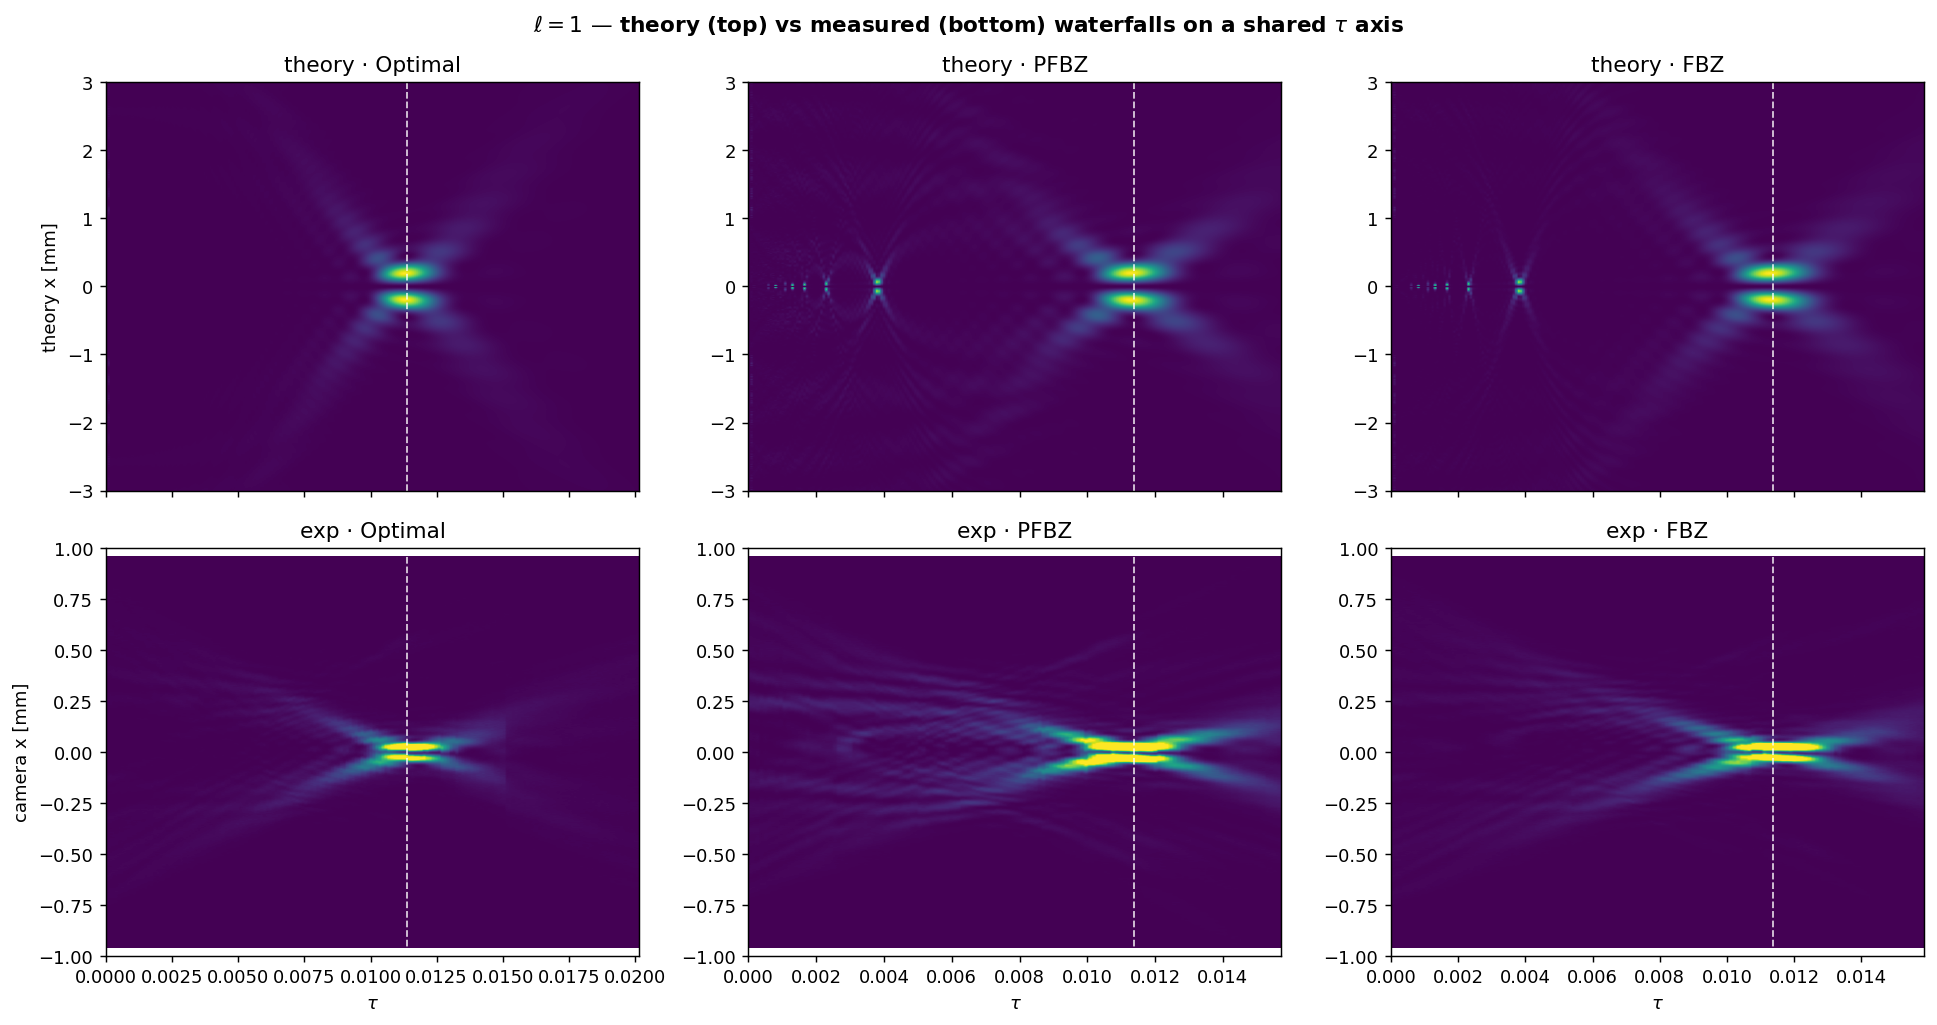

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
order3 = ["Optimal", "PFBZ", "FBZ"]
THEORY_YLIM = 3.0     # theory-plane mm shown
EXP_YLIM = 1.0        # camera mm shown

for c, name in enumerate(order3):
    # theory
    x_mm, img = theory_x_map(THEORY[name], rho_out)
    ax = axes[0, c]
    ax.imshow(img.T, origin="lower", aspect="auto",
              extent=[taus[0], taus[-1], x_mm[0], x_mm[-1]], cmap="viridis", vmin=0, vmax=1)
    ax.axvline(TAU_F, color="w", ls="--", lw=1.0, alpha=0.8)
    ax.set_ylim(-THEORY_YLIM, THEORY_YLIM)
    ax.set_title(f"theory · {name}")
    if c == 0:
        ax.set_ylabel("theory x [mm]")

    # experiment
    st = stitched[name]
    tau = z_to_tau(name, st.z_mm)
    s_mm = st.s_px * PIXEL_PITCH_MM
    ax = axes[1, c]
    ax.imshow(st.waterfall.T, origin="lower", aspect="auto",
              extent=[tau[0], tau[-1], s_mm[0], s_mm[-1]], cmap="viridis", vmin=0, vmax=1)
    ax.axvline(TAU_F, color="w", ls="--", lw=1.0, alpha=0.8)
    ax.set_ylim(-EXP_YLIM, EXP_YLIM)
    ax.set_xlabel(r"$\tau$")
    ax.set_title(f"exp · {name}")
    if c == 0:
        ax.set_ylabel("camera x [mm]")

fig.suptitle(f"$\\ell={L}$ — theory (top) vs measured (bottom) waterfalls on a shared $\\tau$ axis",
             fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "waterfalls_theory_vs_exp_tau.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Notes & next steps

- **Axial map.** The default pins each condition's LG focus to $\tau_f$. If Optimal / PFBZ / FBZ focus
  at slightly different $z$, they get slightly different scales — set `MANUAL_SCALE_MM` to a single
  value to keep those relative focus shifts visible against theory.
- **Transverse crop.** Both theory and experiment RMS widths use the same $\pm$`CROP_HALF_MM` window,
  so far from focus both are limited by the crop; near focus they are not. Widen `CROP_HALF_WIDTH` /
  `CROP_HALF_MM` together if you want the wings.
- **Saturation.** `7-27-26` Optimal clips near focus (see the exposure-compare notebook); the LG fit
  is the clip-robust width, which is why it is the curve overlaid on theory.
- **Extending to other $\ell$.** Set `ELLS` and `L` together and re-run; only $\ell=1$ has the
  extended Optimal segment.
